In [1]:
import pandas as pd
import seaborn as sns 
import numpy as np
import matplotlib.pyplot as plt

In [2]:
bank=pd.read_csv("bank-full.csv",sep=";")

DATASET OVERVIEW

In [3]:
#DATA SHAPE
print(f'The dataset has {bank.shape[0]} rows and {bank.shape[1]} columns')
print(f'The dataset has {sum(bank.isnull().sum())} missing values')
print(f'The dataset has {bank.duplicated().sum()} duplicates')

The dataset has 45211 rows and 17 columns
The dataset has 0 missing values
The dataset has 0 duplicates


In [4]:
#SUMMARY OF THE FIRST FIVE ROWS
bank.head()


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [5]:
print(f'{bank["poutcome"].value_counts(normalize=True)}')

""""
 since other is 0.04% it is statistically negligible we
 can combine it with unknown to reduce  catecorical noise
"""

poutcome
unknown    0.817478
failure    0.108403
other      0.040698
success    0.033421
Name: proportion, dtype: float64


'"\n since other is 0.04% it is statistically negligible we\n can combine it with unknown to reduce  catecorical noise\n'

In [6]:
bank["poutcome"]=bank["poutcome"].str.replace("other","unknown")

In [7]:
#maping age group into categories

bank["y"]=bank["y"].map({"no":0,"yes":1})

CUSTOMER PROFILE

WHICH AGE GROUP CLIENTS SUBSCRIBE MORE?


In [8]:
#grouping age into catecories

bins=[17,30,50,100]
labels=["young","middle-aged","retired"]

bank["age_group"]=pd.cut(bank["age"],bins=bins,labels=labels,right=True)

C:\Users\precious\AppData\Local\Temp\ipykernel_12220\80775543.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_sub_rate=bank.groupby("age_group")['y'].mean()


Text(0, 0.5, 'average subscription rate')

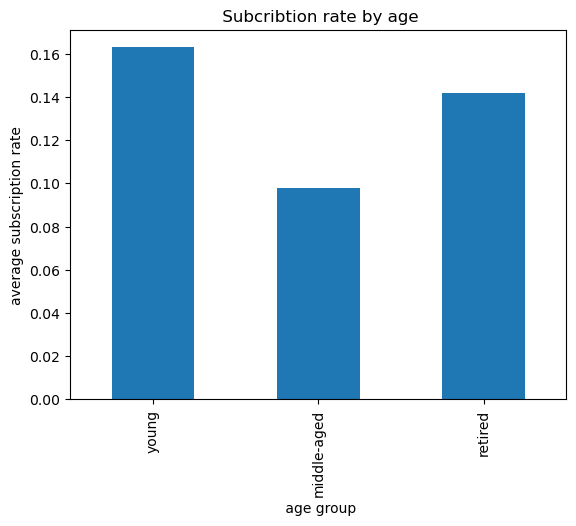

In [9]:
age_sub_rate=bank.groupby("age_group")['y'].mean()
age_sub_rate.plot(kind='bar')
plt.title(" Subcribtion rate by age")
plt.xlabel(" age group")
plt.ylabel("average subscription rate")

young clients often have higher  receptive rate 

**WHICH PROFESSIONS RESPOND BEST TO CAMPAIGNS**

In [21]:
job_conversion_rate=bank.groupby("job")["y"].mean().sort_values(ascending=False)

Text(0, 0.5, 'average subscription rate')

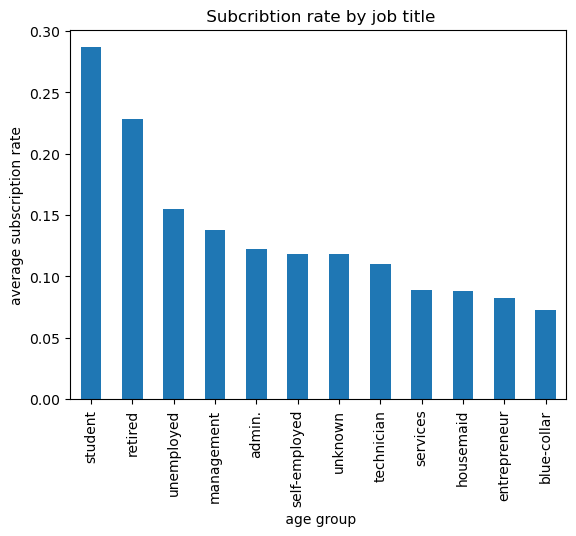

In [24]:
job_conversion_rate.plot(kind='bar')
plt.title(" Subcribtion rate by job title")
plt.xlabel(" age group")
plt.ylabel("average subscription rate")

the analysis show that clients with the job title student have higher subscription rate compared to other professions 
this indicate that student are more receptive to the campain offers than expected dispite having lower balances and limited liquidity

**Do clients with credits defaults subsrcibe at the same rate as those without?**

In [26]:
bank.groupby("default")["y"].mean()

default
no     0.117961
yes    0.063804
Name: y, dtype: float64

suprisingly clients with defaults had a higher subscription rate (11.8%) compared to those without defaults
this suggest that defaults clients may be more motivated to accept deposits or secure safer savings but
their higher responsiveness suggest they are motivated to engage even if they carry higher risk

**HOW DOES DEFAULT STATUS INTERECT WITH OTHER RISK FACTORS**

do defaults status and loan types jointly affect subsciption rates?

In [33]:
con_rate=bank.groupby(["default","housing","loan"])["y"].mean().reset_index()

Text(0.5, 1.0, 'subsription rate by default status and person loan')

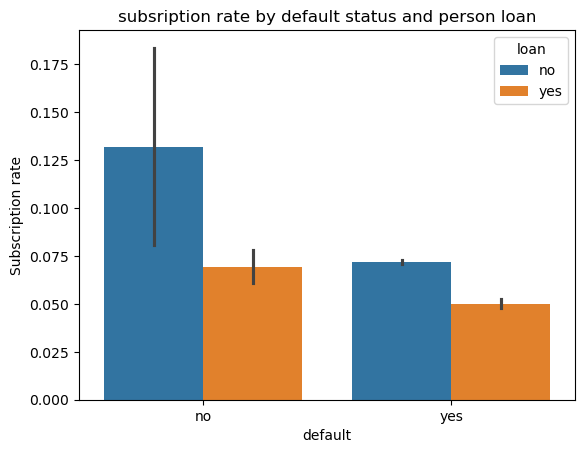

In [37]:
sns.barplot(data=con_rate,x="default",y="y",hue="loan")
plt.ylabel("Subscription rate")
plt.title("subsription rate by default status and person loan")

defaults and loans do jointly affects subsciptions the chart shows that defaulted clients generaly subsribe more but when personal loan the subscription drops this means defaults increase responsiveness while loans dampen it

**DOES CALL DURATION INFLUENCE SUBSCRIPTION RATE**

In [43]:
duration_conv=bank.groupby("y")["duration"].mean()
duration_conv

y
0    221.182806
1    537.294574
Name: duration, dtype: float64

longer calls results in higher conversation rate this may lead the business to train to extend conversationsand use duaration as a real kpi for prioritizing follow-ups

**DOES THE NUMBER OF TIMES A CLIENT WAS CONTACTED DURING THE CAMPAIGN AFFECT SUBSCRIPTION**

In [45]:
bank.groupby("campaign")["y"].agg(['mean','count']).reset_index()

,campaign,mean,count
0,1,0.145976,17544
1,2,0.112035,12505
2,3,0.111936,5521
3,4,0.090006,3522
4,5,0.078798,1764
5,6,0.071263,1291
6,7,0.063946,735
7,8,0.059259,540
8,9,0.064220,327
9,10,0.052632,266
